In [232]:
import pandas as pd
import geopandas as gpd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

import utils.cross_validation as cval
import random 
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
import pandas as pd
import utils.model_utils as mu
import utils.eval_utils as ev
import shap
import numpy as np
from sklearn.inspection import partial_dependence
import utils.model_utils as mu
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from matplotlib.lines import Line2D

In [249]:
from sklearn.inspection import partial_dependence
from scipy.ndimage import gaussian_filter1d

In [ ]:
def SHAP_plots_v1(model_f, model_s, X_test_f, X_test_s, colour_f="#4b72f1", colour_s="#c88f8f"):
    
    explainer_f = shap.TreeExplainer(model_f)
    shap_values_f = explainer_f(X_test_f, approximate=True)
    
    explainer_s = shap.TreeExplainer(model_s)
    shap_values_s = explainer_s(X_test_s, approximate=True)

    fig, (ax_f, ax_s) = plt.subplots(1, 2, figsize=(14, 6))

    # ── Left: functional diversity ──
    plt.sca(ax_f)
    shap.plots.bar(shap_values_f.abs.mean(0), max_display=len(X_test_f.columns), show=False, ax=ax_f)
    for bar in ax_f.patches:
        bar.set_color(colour_f)
    ax_f.spines["right"].set_visible(True)
    ax_f.spines["left"].set_visible(True)

    # ── Right: species diversity — inverted ──
    plt.sca(ax_s)
    shap.plots.bar(shap_values_s.abs.mean(0), max_display=len(X_test_s.columns), show=False, ax=ax_s)
    for bar in ax_s.patches:
        bar.set_color(colour_s)
    ax_s.invert_xaxis()
    ax_s.yaxis.set_label_position("right")
    ax_s.yaxis.tick_right()
    ax_s.spines["right"].set_visible(True)
    ax_s.spines["left"].set_visible(True)
    for text in ax_s.texts:
        x, y = text.get_position()
        text.set_position((x + 0.03, y))

    # ── Align x axes ──
    max_val = max(ax_f.get_xlim()[1], ax_s.get_xlim()[0])  # ax_s is inverted so take [0]
    ax_f.set_xlim(0, max_val)
    ax_s.set_xlim(max_val, 0)  # inverted

    plt.tight_layout()
    plt.show()

    shap_df_f = pd.DataFrame(shap_values_f.values, columns=X_test_f.columns, index=X_test_f.index)
    shap_df_s = pd.DataFrame(shap_values_s.values, columns=X_test_s.columns, index=X_test_s.index)

    return shap_df_f, explainer_f, shap_df_s, explainer_s

def SHAP_plots(model_f, model_s, X_test_f, X_test_s,
               display_features_f, display_features_s,
               sum_features_f, sum_features_s,
               sum_label_f="Summed FD", sum_label_s="Summed SD",
               colour_f="#4b72f1", colour_s="#c88f8f"):

    explainer_f = shap.TreeExplainer(model_f)
    shap_values_f = explainer_f(X_test_f, approximate=True)
    explainer_s = shap.TreeExplainer(model_s)
    shap_values_s = explainer_s(X_test_s, approximate=True)

    shap_df_f = pd.DataFrame(shap_values_f.values, columns=X_test_f.columns, index=X_test_f.index)
    shap_df_s = pd.DataFrame(shap_values_s.values, columns=X_test_s.columns, index=X_test_s.index)

    # ── Sum specified features into one row ──
    def build_plot_df(shap_df, display_features, sum_features, sum_label):
        mean_abs = shap_df.abs().mean()
        plot_vals = mean_abs[display_features].to_dict()
        plot_vals[sum_label] = shap_df[sum_features].abs().sum(axis=1).mean()
        return pd.Series(plot_vals).sort_values(ascending=True)

    plot_f = build_plot_df(shap_df_f, display_features_f, sum_features_f, sum_label_f)
    plot_s = build_plot_df(shap_df_s, display_features_s, sum_features_s, sum_label_s)

    max_val = max(plot_f.max(), plot_s.max())

    fig, (ax_f, ax_s) = plt.subplots(1, 2, figsize=(14, 6))

    # ── Left: functional diversity ──
    ax_f.barh(plot_f.index, plot_f.values, color=colour_f)
    ax_f.set_xlim(0, max_val * 1.1)
    ax_f.spines[["right", "top"]].set_visible(False)
    ax_f.set_xlabel("mean |SHAP|")

    # ── Right: species diversity — inverted ──
    ax_s.barh(plot_s.index, plot_s.values, color=colour_s)
    ax_s.invert_xaxis()
    ax_s.yaxis.set_label_position("right")
    ax_s.yaxis.tick_right()
    ax_s.set_xlim(max_val * 1.1, 0)
    ax_s.spines[["left", "top"]].set_visible(False)
    ax_s.set_xlabel("mean |SHAP|")

    plt.tight_layout()
    plt.show()

    return shap_df_f, explainer_f, shap_df_s, explainer_s

def plot_pdp(div_f, div_s, fd_model, sd_model, fX_test, sX_test, name="pdp_plot.png"):

    paired_vars = list(zip(div_f, div_s))

    colors_f = "#176248"
    colors_s = "#e39579"

    # 2 rows x 3 cols
    fig, axes = plt.subplots(1, 2, figsize=(8, 2))
    axes_flat = axes.flatten()  # flatten to iterate easily
    fig.subplots_adjust(hspace=0.6)  # increase from default ~0.2
    fig.subplots_adjust(wspace=0.4)  # increase space between plots

    plt.rcParams.update({'font.size': 8}) 
    for ax, (f_var, s_var) in zip(axes_flat, paired_vars):

        pd_f = partial_dependence(fd_model, fX_test, features=[f_var], grid_resolution=200,  kind="individual")
        pd_s = partial_dependence(sd_model, sX_test, features=[s_var], grid_resolution=200,  kind="individual")

        x_f = pd_f["grid_values"][0]
        x_s = pd_s["grid_values"][0]
        y_f = pd_f["average"][0]
        y_s = pd_s["average"][0]

        # ── Bottom x-axis: species diversity ──
        ax.plot(x_s, y_s, color=colors_s, linewidth=2, linestyle="--")
        ax.set_xlabel(s_var)
        ax.tick_params(axis="x")

        # ── Top x-axis: functional diversity ──
        ax_top = ax.twiny()
        ax_top.plot(x_f, y_f, color=colors_f, linewidth=2)
        ax_top.set_xlabel(f_var)
        ax_top.tick_params(axis="x")

        # y label only on leftmost column
        ax.set_ylabel("Influence on Ecosystem Stability" if ax == axes[0] else "")
        ax.spines[["right"]].set_visible(False)
        ax_top.spines[["right"]].set_visible(False)

    # legend_elements = [
    #     Line2D([0], [0], color=colors_f, linewidth=2, label='Functional Diversity'),
    #     Line2D([0], [0], color=colors_s, linewidth=2, linestyle='--', label='Species Diversity')
    # ]
    # fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.25))
    fig.savefig(name, dpi=150, bbox_inches="tight")
        

In [210]:
biome_mapping = {
        0: 'Boreal and Tundra forests',
        1: 'Flooded grasslands',
        2: 'Mangroves',
        3: 'Mediterranean woodlands',
        4: 'Temperate broadleaf forests',
        5: 'Temperate conifer forests',
        6: 'Temperate grasslands',
        7: 'Tropical',
        8: 'Tropical',
        9: 'Tropical',
        10: 'Tropical',
        11: 'Boreal and Tundra forests',
        12: 'Xeric shrublands',
        13: np.nan
    }

def quick_eval(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
    r2 = r2_score(y_test, y_pred, multioutput='raw_values')
    return mae, r2

def train_test_split(df, random_key, test_size):
    sub_df = df.drop(columns=['BHAGE', 'managed',
        'ownership', 'biome', 'geometry', 'index_right', 'lat', 'lon', 'DIA',
        'lon_bin', 'lat_bin', 'TPA_UNADJ', 'WSCI'])

    sets=list(set(sub_df['ECO_NAME']))
 

    random.seed(random_key)
    test_set = random.sample(sets, int(test_size * len(sets)))
    test = sub_df[sub_df["ECO_NAME"].isin(test_set)]
    train = sub_df[~sub_df["ECO_NAME"].isin(test_set)]

    y=['transformed npp'] 
    X_train=train.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
    y_train = train['transformed npp'].values

    X_test= test.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
    y_test = test['transformed npp'].values
    
    scaler= StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    return X_train, y_train, X_test, y_test

def data_processing_v2(df, biome_mapping):
     
    # df = df[df['biome'].isin([4,5,6,12])]

    df["biome"] = df["biome"].replace(biome_mapping)

    df=cval.assign_spatial_groups(df, grid_size=1.0)

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326"  # WGS84
    )

    joined = gpd.sjoin(gdf, ecoregions, how="left", predicate="within")

    biome_dfs = {k: v for k, v in joined.groupby('biome')}
    return biome_dfs

In [192]:

fd_df= pd.read_csv("data/final/fd_df.csv")
sd_df = pd.read_csv("data/final/sd_df.csv")

ecoregions=cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")

ecoregions=ecoregions[['ECO_NAME', 'geometry']]

fd_df = fd_df.loc[:, ~fd_df.columns.str.contains(r'\.1')]
sd_df = sd_df.loc[:, ~sd_df.columns.str.contains(r'\.1')]

fd_df.drop(columns=['Mean Pairwise D'], inplace=True)
fd_df.dropna(subset=['TPA_UNADJ'], inplace=True) # Maybe exclude

sd_df.dropna(subset=['TPA_UNADJ'], inplace=True) # Maybe exclude
# sd_df = sd_df[sd_df["WSCI"] >= -1000]
# fd_df = fd_df[fd_df["WSCI"] >= -1000]


sd_df.columns = sd_df.columns.str.replace('_x$', '', regex=True)
sd_df.columns = sd_df.columns.str.replace('_y$', '', regex=True)

sd_df = sd_df.loc[:, ~sd_df.columns.duplicated()]

shared_pids = set(sd_df["PID"]).intersection(fd_df["PID"])

# Filter both dataframes to only shared PIDs
sd_df = sd_df[sd_df["PID"].isin(shared_pids)]
fd_df = fd_df[fd_df["PID"].isin(shared_pids)]

#Preprocessing the data for Random forest regression

fbiome_dfs= data_processing_v2(fd_df, biome_mapping)
sbiome_dfs =data_processing_v2(sd_df, biome_mapping)

In [180]:
fd_df['biome'].value_counts()

biome
Temperate broadleaf forests    31227
Temperate conifer forests      10188
Temperate grasslands            8914
Xeric shrublands                 991
Boreal and Tundra forests        239
Tropical                         159
Flooded grasslands                28
Mediterranean woodlands           24
Mangroves                         11
Name: count, dtype: int64

In [243]:
biomes_list=['Temperate broadleaf forests','Temperate conifer forests',
            'Temperate grasslands', 'Xeric shrublands', 'Boreal and Tundra forests' ]

# biomes_list=['Boreal and Tundra forests']

In [ ]:
from sklearn.inspection import partial_dependence
from scipy.ndimage import gaussian_filter1d


Biome: Temperate broadleaf forests
Functional Diversity - MAE: [0.2844437], R²: [0.51378888]
Species Diversity - MAE: [0.28369631], R²: [0.51746424]
Biome: Temperate conifer forests
Functional Diversity - MAE: [0.73260419], R²: [-2.02364562]
Species Diversity - MAE: [0.73854238], R²: [-2.07139457]
Biome: Temperate grasslands
Functional Diversity - MAE: [0.19375919], R²: [0.31120716]
Species Diversity - MAE: [0.19004694], R²: [0.33388089]
Biome: Xeric shrublands
Functional Diversity - MAE: [0.34166459], R²: [-1.40594322]
Species Diversity - MAE: [0.30290369], R²: [-0.94887043]
Biome: Boreal and Tundra forests
Functional Diversity - MAE: [0.18328956], R²: [0.24036788]
Species Diversity - MAE: [0.17666572], R²: [0.25558627]


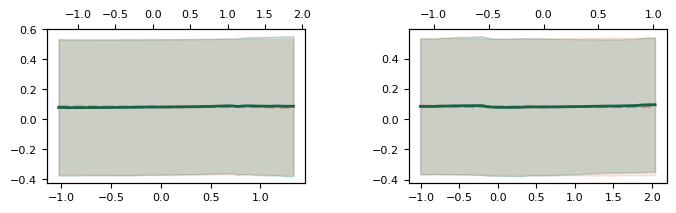

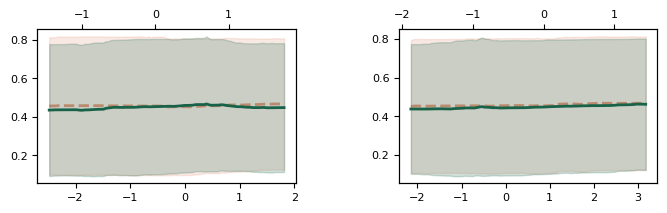

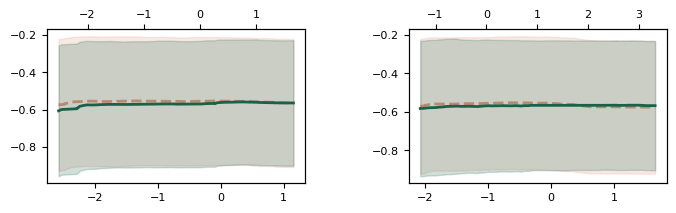

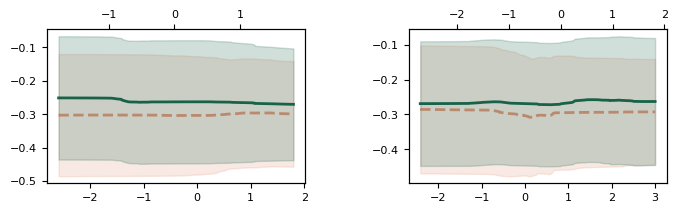

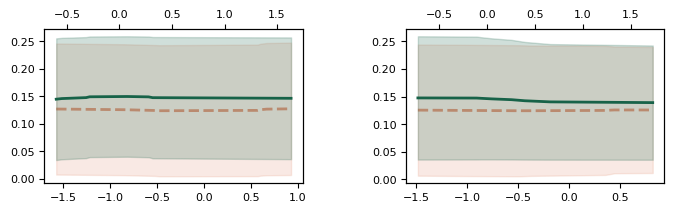

In [254]:
for biome in biomes_list:
    print(f"Biome: {biome}")
    fX_train, fy_train, fX_test, fy_test = train_test_split(fbiome_dfs[biome], random_key=42, test_size=0.2)
    sX_train, sy_train, sX_test, sy_test = train_test_split(sbiome_dfs[biome], random_key=42, test_size=0.2)

    fd_reg = RandomForestRegressor(random_state=42, n_jobs=4)
    sd_reg = RandomForestRegressor(random_state=42, n_jobs=4)

    fd_reg.fit(fX_train, fy_train)
    sd_reg.fit(sX_train, sy_train)

    fd_mae, fd_r2 = quick_eval(fd_reg, fX_test, fy_test)
    sd_mae, sd_r2 = quick_eval(sd_reg, sX_test, sy_test)

    print(f"Functional Diversity - MAE: {fd_mae}, R²: {fd_r2}")
    print(f"Species Diversity - MAE: {sd_mae}, R²: {sd_r2}")

    diversity_vars_f = ['Raos_Q', 'Functional_Evenness']
    diversity_vars_s = ["Simpson's Index", 'Shannon Diversity']
    plot_name = f"results/pdp_{biome.replace(' ', '_')}.png"
    plot_pdp(diversity_vars_f, diversity_vars_s, fd_reg, sd_reg, fX_test, sX_test, plot_name)


In [181]:
fsub_df=fbiome_dfs['Temperate conifer forests']
ssub_df=sbiome_dfs['Temperate conifer forests']

In [182]:
fX_train, fy_train, fX_test, fy_test = train_test_split(fsub_df, 42, 0.2)
sX_train, sy_train, sX_test, sy_test = train_test_split(ssub_df, 42, 0.2)

# f_cols = ["Raos_Q", "Functional_Evenness", "Species Richness", "WSCI"]  # replace with your columns
# s_cols = ["Simpson's Index", 'Shannon Diversity', 'Species Richness', 'WSCI']  # replace with your columns

# fX_test = fX_test[f_cols]
# fX_train = fX_train[f_cols]
# sX_test = sX_test[s_cols]
# sX_train= sX_train[s_cols]

In [183]:

fd_reg=RandomForestRegressor(
    random_state=42,
    n_jobs=4
)

sd_reg=RandomForestRegressor(
    random_state=42,
    n_jobs=4
)

sd_reg.fit(sX_train, sy_train)
fd_reg.fit(fX_train, fy_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [184]:
smae, sr2 = quick_eval(sd_reg, sX_test, sy_test)  
fmae, fr2 = quick_eval(fd_reg, fX_test, fy_test)

print(f"SD MAE: {smae}, SD R2: {sr2}")
print(f"FD MAE: {fmae}, FD R2: {fr2}")

SD MAE: [0.73854238], SD R2: [-2.07139457]
FD MAE: [0.73260419], FD R2: [-2.02364562]


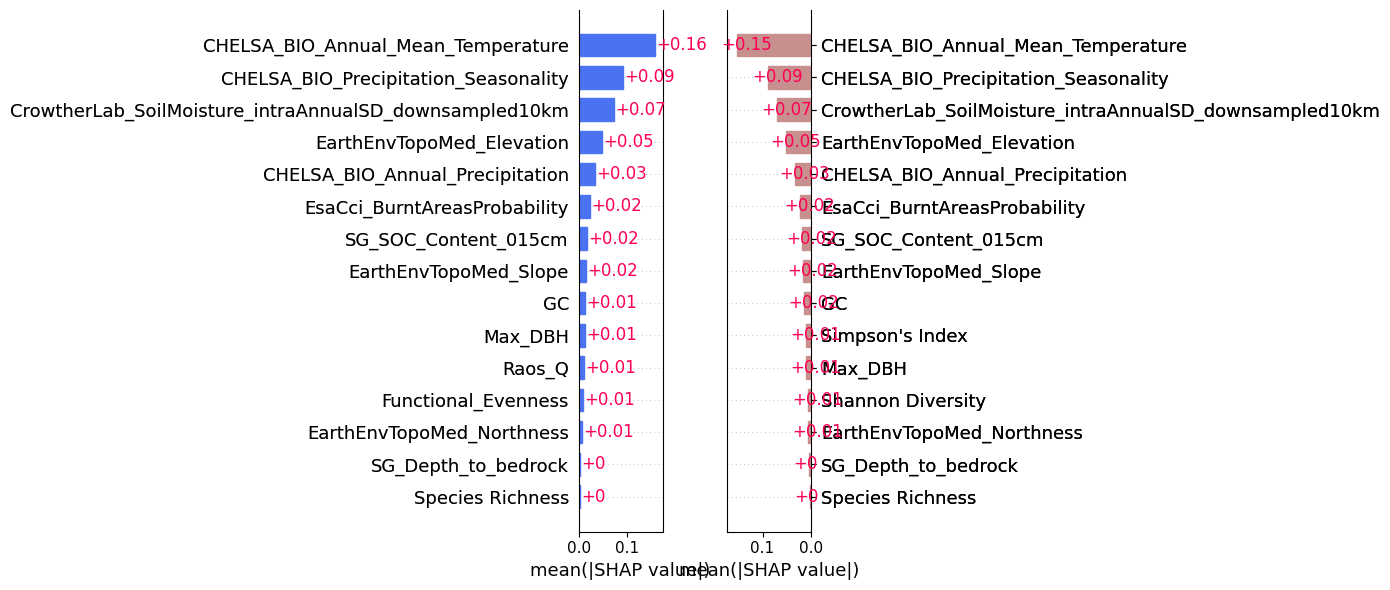

In [185]:
from sklearn.inspection import partial_dependence
import matplotlib.pyplot as plt


fshap_df, fexplainer, sshap_df, sexplainer = SHAP_plots_v1(
    fd_reg, sd_reg, fX_test, sX_test
)


In [200]:
sX_test.columns

Index(['CHELSA_BIO_Annual_Mean_Temperature', 'CHELSA_BIO_Annual_Precipitation',
       'CHELSA_BIO_Precipitation_Seasonality',
       'CrowtherLab_SoilMoisture_intraAnnualSD_downsampled10km',
       'SG_SOC_Content_015cm', 'EsaCci_BurntAreasProbability',
       'EarthEnvTopoMed_Elevation', 'EarthEnvTopoMed_Slope',
       'SG_Depth_to_bedrock', 'EarthEnvTopoMed_Northness', 'Species Richness',
       'Shannon Diversity', 'Simpson's Index', 'GC', 'Max_DBH'],
      dtype='str')

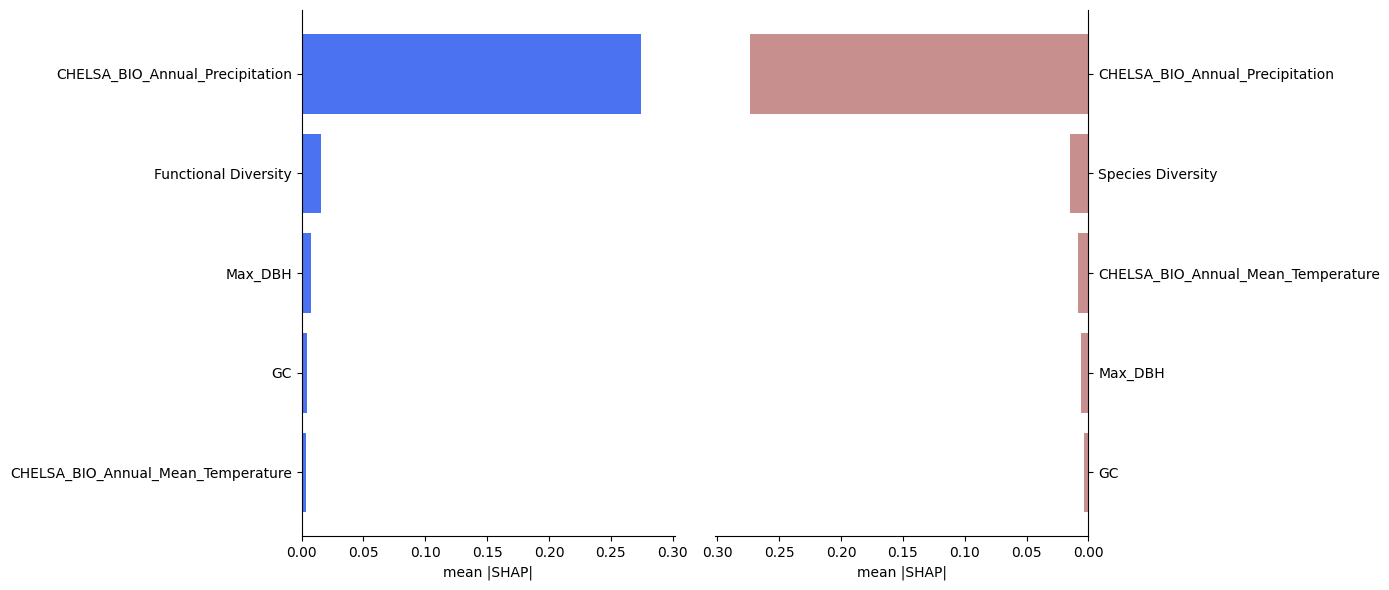

In [202]:
shap_df_f, explainer_f, shap_df_s, explainer_s = SHAP_plots(
    model_f=fd_reg,
    model_s=sd_reg,
    X_test_f=fX_test,
    X_test_s=sX_test,
    display_features_f=['CHELSA_BIO_Annual_Mean_Temperature', 'CHELSA_BIO_Annual_Precipitation','GC', 'Max_DBH'],
    display_features_s=['CHELSA_BIO_Annual_Mean_Temperature', 'CHELSA_BIO_Annual_Precipitation','GC', 'Max_DBH',],
    sum_features_f=['Raos_Q', 'Functional_Evenness', 'Species Richness'],
    sum_features_s=['Species Richness','Shannon Diversity', "Simpson's Index"],
    sum_label_f="Functional Diversity",
    sum_label_s="Species Diversity"
)

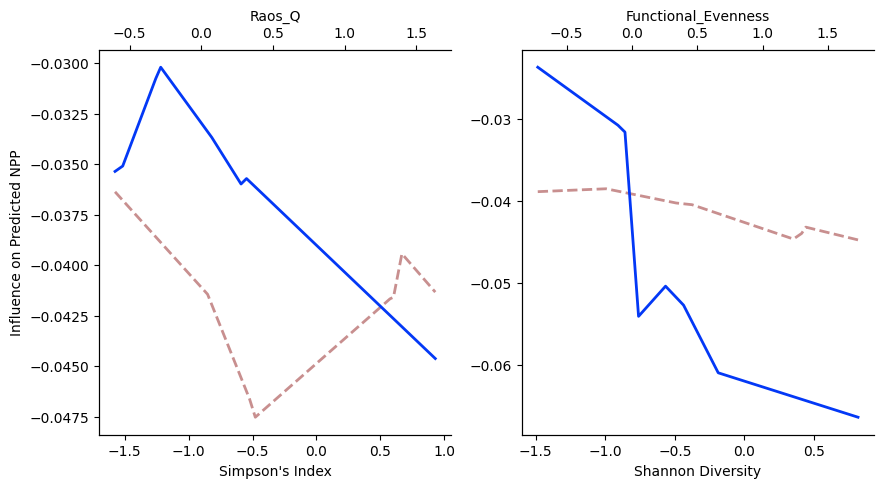

In [ ]:
def plot_fd_heatmap(model, X_test, y_test, feature_x, feature_y,
                    fd_features=["Raos_Q", "Functional_Evenness"],
                    bins=20, cmap="viridis", r2_threshold=0.2):

    df = X_test.copy()
    df["_y_true"] = y_test.values if hasattr(y_test, "values") else y_test
    df["_y_pred"] = model.predict(X_test)
    df["_fd_sum"] = df[fd_features].sum(axis=1)

    df["_bin_x"] = pd.cut(df[feature_x], bins=bins)
    df["_bin_y"] = pd.cut(df[feature_y], bins=bins)

    fd_matrix = (
        df.groupby(["_bin_y", "_bin_x"], observed=True)["_fd_sum"]
        .mean()
        .unstack("_bin_x")
    )

    def safe_r2(g):
        if len(g) < 2:
            return np.nan
        return r2_score(g["_y_true"], g["_y_pred"])

    r2_matrix = (
        df.groupby(["_bin_y", "_bin_x"], observed=True)
        .apply(safe_r2)
        .unstack("_bin_x")
    )

    def midpoints(intervals):
        return [i.mid for i in intervals]

    x_mids = midpoints(fd_matrix.columns)
    y_mids = midpoints(fd_matrix.index)

    fig, ax = plt.subplots(figsize=(10, 8))

    sns.heatmap(
        fd_matrix,
        cmap=cmap,
        ax=ax,
        xticklabels=[f"{v:.2f}" for v in x_mids],
        yticklabels=[f"{v:.2f}" for v in y_mids],
        linewidths=0.3,
        linecolor="white",
        cbar_kws={"label": f"Mean summed FD ({' + '.join(fd_features)})"}
    )
    ax.invert_yaxis()

    # ── overlay black patches where R² <= threshold ──
    for i, row in enumerate(r2_matrix.index):
        for j, col in enumerate(r2_matrix.columns):
            r2_val = r2_matrix.loc[row, col]
            if np.isnan(r2_val) or r2_val <= r2_threshold:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, color="black", zorder=2))

    n = max(1, bins // 8)
    ax.set_xticks(ax.get_xticks()[::n])
    ax.set_xticklabels(ax.get_xticklabels()[::n], rotation=45, ha="right")
    ax.set_yticks(ax.get_yticks()[::n])
    ax.set_yticklabels(ax.get_yticklabels()[::n], rotation=0)

    ax.set_xlabel(feature_x)
    ax.set_ylabel(feature_y)
    ax.set_title(f"Mean FD ({' + '.join(fd_features)})\nacross {feature_x} vs {feature_y} | black = R² ≤ {r2_threshold}")

    plt.tight_layout()
    plt.savefig(f"fd_heatmap_{feature_x}_{feature_y}.png", dpi=150, bbox_inches="tight")
    plt.show()

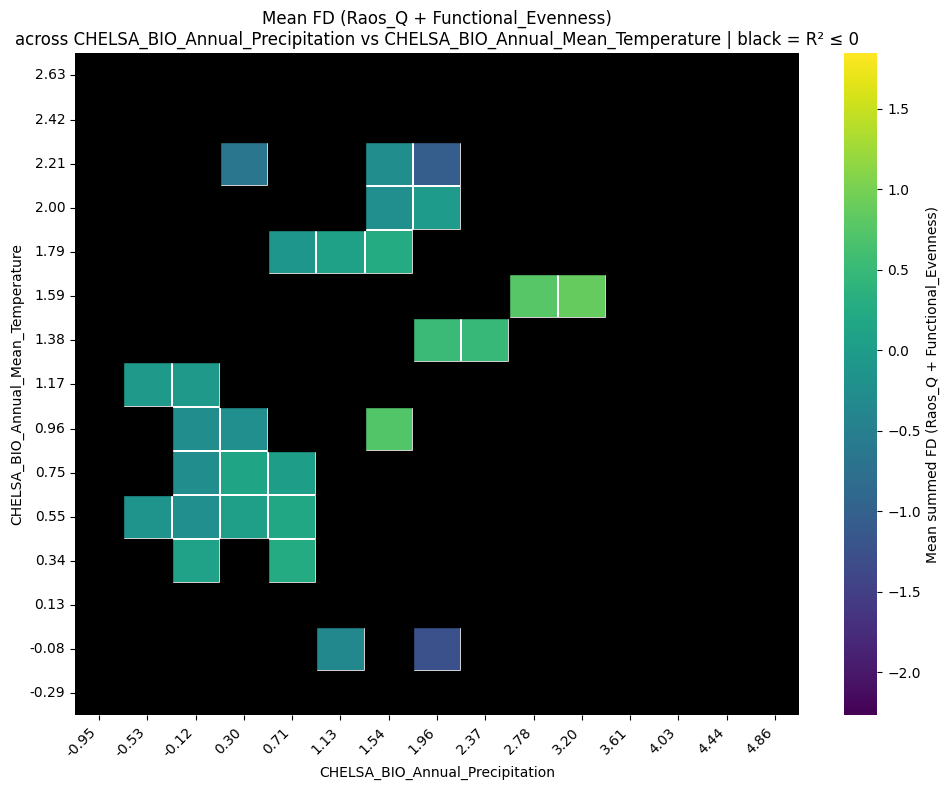

In [ ]:
plot_fd_heatmap(
    model=fd_reg,
    X_test=fX_test,
    y_test=fy_test,
    feature_x="CHELSA_BIO_Annual_Precipitation",
    feature_y="CHELSA_BIO_Annual_Mean_Temperature",
    fd_features=["Raos_Q", "Functional_Evenness"],
    bins=15,
    r2_threshold=-0
)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

def plot_r2_heatmap(model, X_test, y_test, feature_x, feature_y, bins=20, cmap="RdYlGn"):
    """
    Plots a heatmap where colour = R² computed on samples
    falling within each (feature_x, feature_y) bin.
    """
    df = X_test.copy()
    df["_y_true"] = y_test.values if hasattr(y_test, "values") else y_test
    df["_y_pred"] = model.predict(X_test)

    # bin the two features
    df["_bin_x"] = pd.cut(df[feature_x], bins=bins)
    df["_bin_y"] = pd.cut(df[feature_y], bins=bins)

    # compute R² per bin
    def safe_r2(g):
        if len(g) < 2:
            return np.nan
        return r2_score(g["_y_true"], g["_y_pred"])

    r2_matrix = (
        df.groupby(["_bin_y", "_bin_x"], observed=True)
        .apply(safe_r2)
        .unstack("_bin_x")
    )

    # readable tick labels (bin midpoints)
    def midpoints(intervals):
        return [f"{i.mid:.2f}" for i in intervals]

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        r2_matrix,
        cmap=cmap,
        vmin=-1, vmax=1,
        center=0,
        ax=ax,
        xticklabels=midpoints(r2_matrix.columns),
        yticklabels=midpoints(r2_matrix.index),
        linewidths=0.3,
        linecolor="white",
        cbar_kws={"label": "R²"}
    )
    ax.invert_yaxis()
    ax.set_xlabel(feature_x)
    ax.set_ylabel(feature_y)
    ax.set_title(f"R² heatmap: {feature_x} vs {feature_y}")

    # only show every Nth tick to avoid crowding
    n = max(1, bins // 8)
    ax.set_xticks(ax.get_xticks()[::n])
    ax.set_xticklabels(ax.get_xticklabels()[::n], rotation=45, ha="right")
    ax.set_yticks(ax.get_yticks()[::n])
    ax.set_yticklabels(ax.get_yticklabels()[::n], rotation=0)

    plt.tight_layout()
    plt.savefig(f"r2_heatmap_{feature_x}_{feature_y}.png", dpi=150, bbox_inches="tight")
    plt.show()

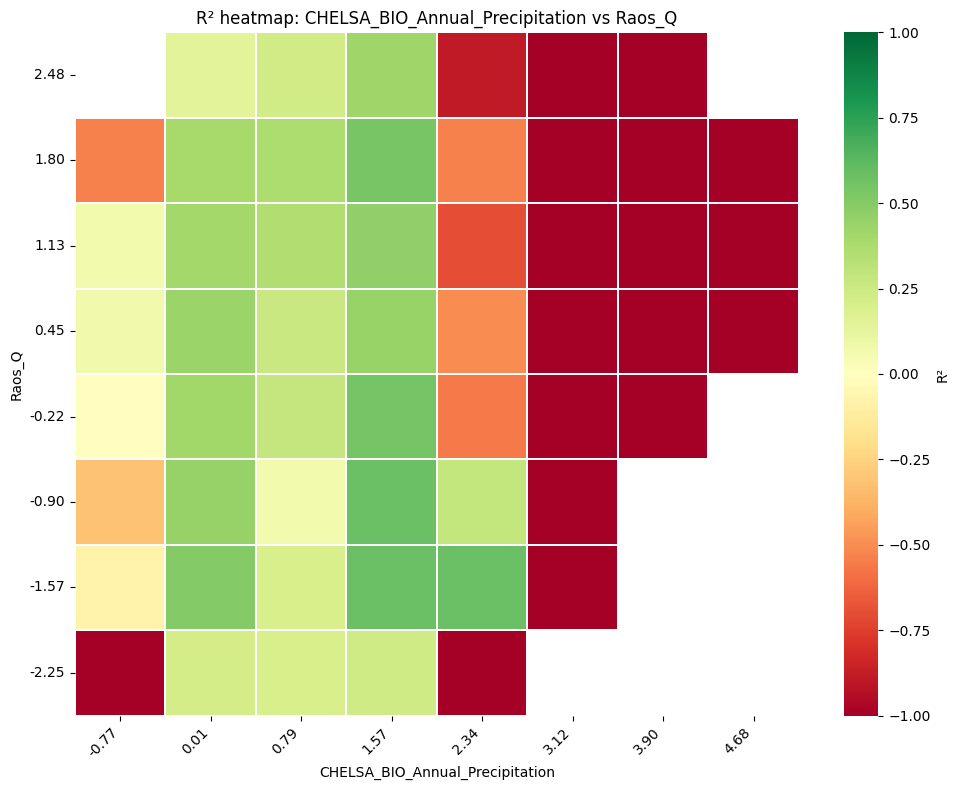

In [ ]:
plot_r2_heatmap(fd_reg, fX_test, fy_test, feature_x='CHELSA_BIO_Annual_Precipitation', feature_y='Raos_Q', bins=8)

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

def test_collinearity(df, variables):
    
    # ── 1. Correlation matrix ──
    print("=== Pearson Correlation Matrix ===")
    corr = df[variables].corr()
    print(corr.round(3))

    # ── 2. Pairwise p-values ──
    print("\n=== Pairwise Correlation P-values ===")
    for i, v1 in enumerate(variables):
        for v2 in variables[i+1:]:
            r, p = stats.pearsonr(df[v1].dropna(), df[v2].dropna())
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
            print(f"{v1} vs {v2}: r={r:.3f}, p={p:.4f} {sig}")

    # ── 3. Variance Inflation Factor (VIF) ──
    print("\n=== Variance Inflation Factor (VIF) ===")
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X = df[variables].dropna()
    vif_data = pd.DataFrame({
        "Feature": variables,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(len(variables))]
    })
    print(vif_data.round(3))
    print("\nVIF > 5 = moderate collinearity, VIF > 10 = high collinearity")

    return corr, vif_data

corr, vif = test_collinearity(fsub_df, ["CHELSA_BIO_Annual_Mean_Temperature", "CHELSA_BIO_Annual_Precipitation", "Functional_Evenness", "Raos_Q", "Species Richness"])

=== Pearson Correlation Matrix ===
                                    CHELSA_BIO_Annual_Mean_Temperature  \
CHELSA_BIO_Annual_Mean_Temperature                               1.000   
CHELSA_BIO_Annual_Precipitation                                  0.473   
Functional_Evenness                                             -0.170   
Raos_Q                                                           0.137   
Species Richness                                                 0.468   

                                    CHELSA_BIO_Annual_Precipitation  \
CHELSA_BIO_Annual_Mean_Temperature                            0.473   
CHELSA_BIO_Annual_Precipitation                               1.000   
Functional_Evenness                                          -0.177   
Raos_Q                                                        0.193   
Species Richness                                              0.313   

                                    Functional_Evenness  Raos_Q  \
CHELSA_BIO_Annual_Mean_Tem